In [33]:
import sys
import numpy as np
import numpy.core as npcore
import numpy.core.multiarray as multiarray
import numpy.core.umath as umath
import joblib
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import FormatStrFormatter



sys.modules["numpy._core"] = npcore
sys.modules["numpy._core.multiarray"] = multiarray
sys.modules["numpy._core.umath"] = umath




In [34]:
path = "resdict_dir=-_Re=50-50_Ra=1e+03-7e+04_nx=ny=131.joblib"
obj = joblib.load(path)

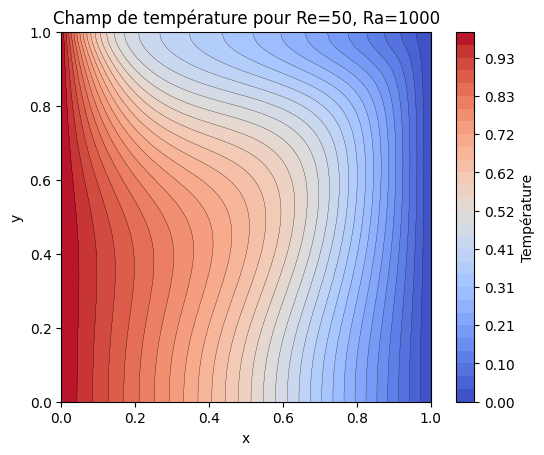

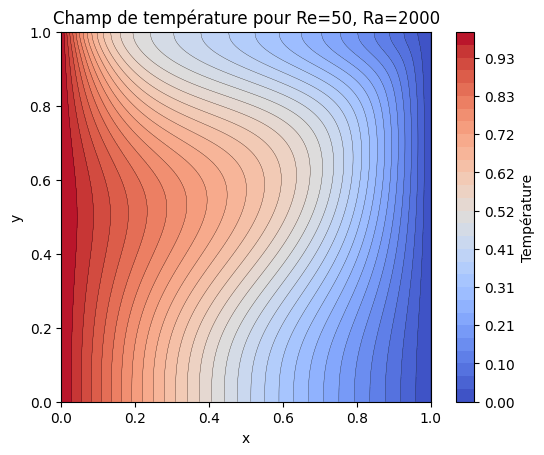

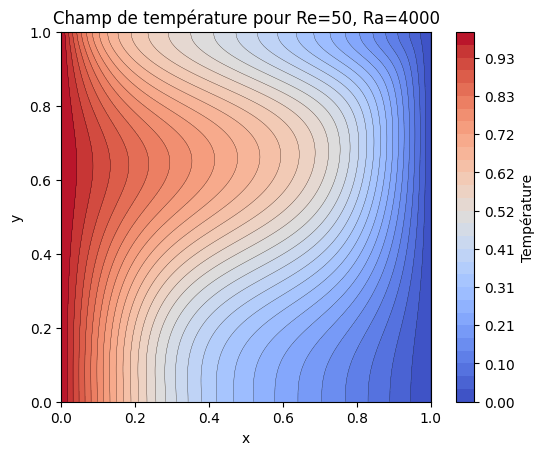

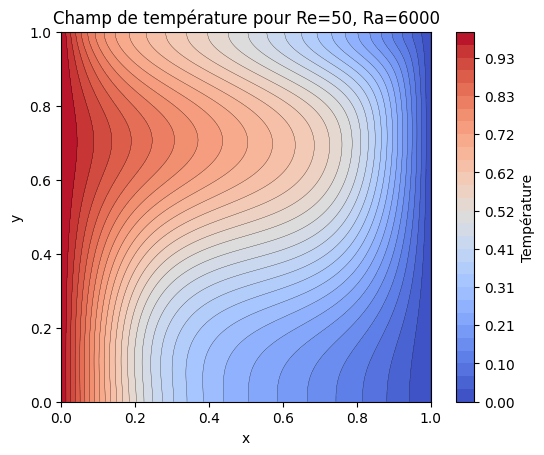

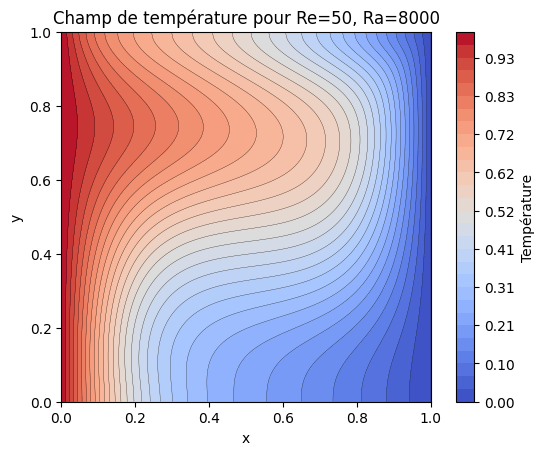

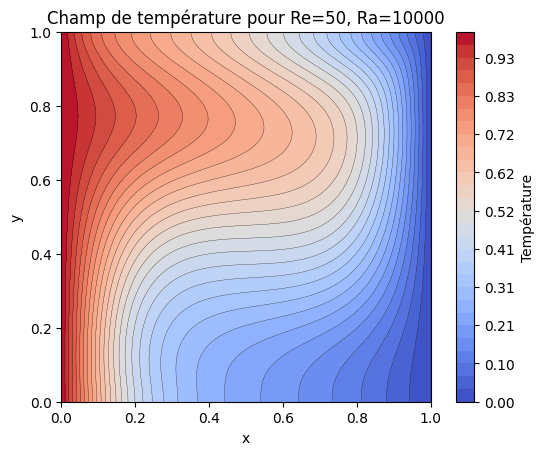

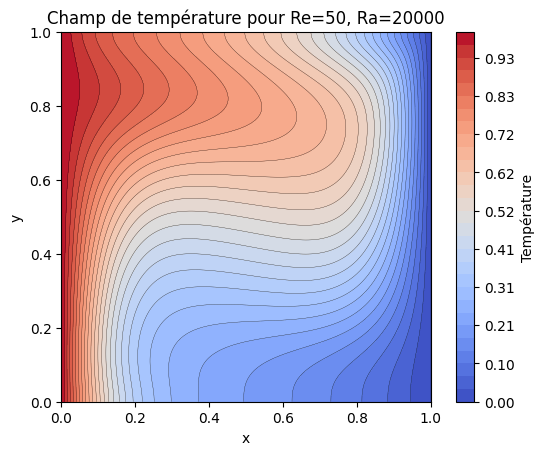

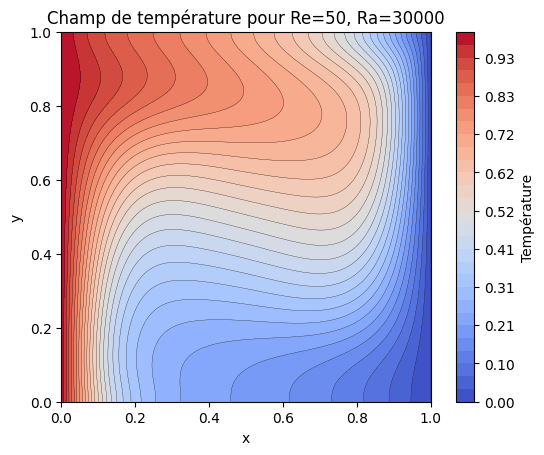

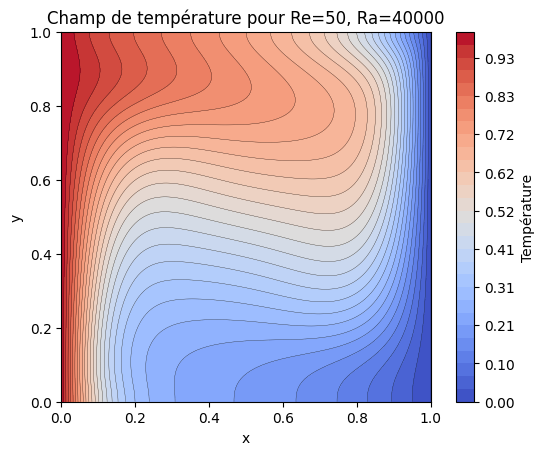

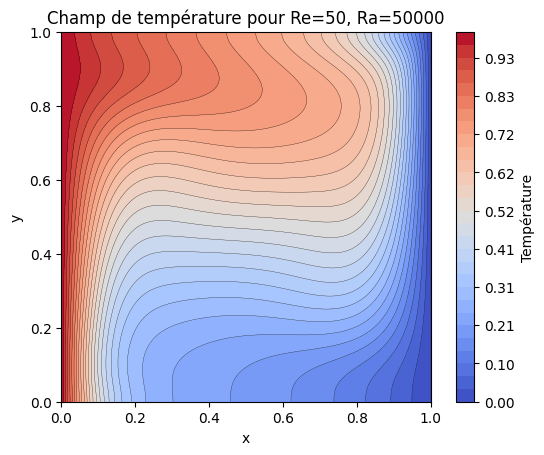

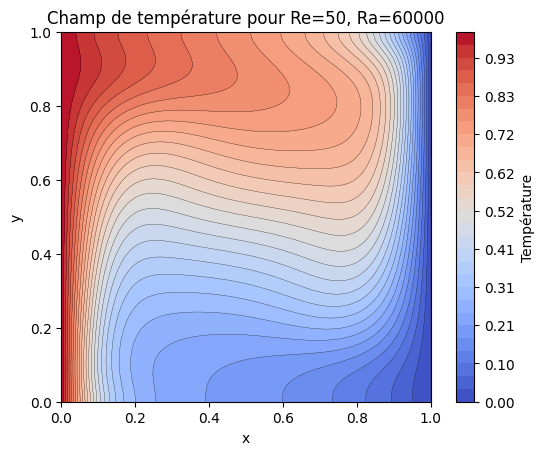

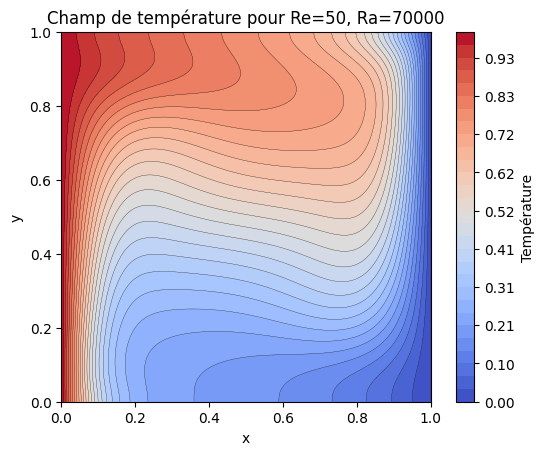

In [35]:
dir_key = "-"
Re = 50
Ra_list = sorted(obj[dir_key][Re].keys())

snapshot_index = -1
n_iso = 30
cmap = "coolwarm"
use_contour_lines = True

x0, x1 = 0.0, 1.0
y0, y1 = 0.0, 1.0
tick_step = 0.2

out_dir = f"Re={Re}_Direction={dir_key}"
os.makedirs(out_dir, exist_ok=True)

def safe_str(x: str) -> str:
    return (
        str(x)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "")
        .replace(":", "_")
        .replace("'", "")
        .replace('"', "")
    )

for Ra in Ra_list:
    d = obj[dir_key][Re][Ra]
    T = np.asarray(d["T"][snapshot_index])

    vmin, vmax = float(np.nanmin(T)), float(np.nanmax(T))
    levels = np.linspace(vmin, vmax, n_iso)

    plt.figure()
    extent = [x0, x1, y0, y1]

    cf = plt.contourf(T, levels=levels, cmap=cmap, extent=extent)
    cbar = plt.colorbar(cf, label="Température")
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # 2 décimales

    if use_contour_lines:
        plt.contour(
            T,
            levels=levels,
            colors="k",
            linewidths=0.2,
            alpha=1.0,
            extent=extent
        )

    ax = plt.gca()
    ax.set_aspect("equal")
    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)

    ticks = np.arange(0.0, 1.0001, tick_step)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Champ de température pour Re={Re}, Ra={Ra:g}")

    filename = f"Champ_T_Re={Re}_Dir={safe_str(dir_key)}_Ra={Ra:g}.png"
    plt.savefig(os.path.join(out_dir, filename), dpi=200, bbox_inches="tight")

plt.show()

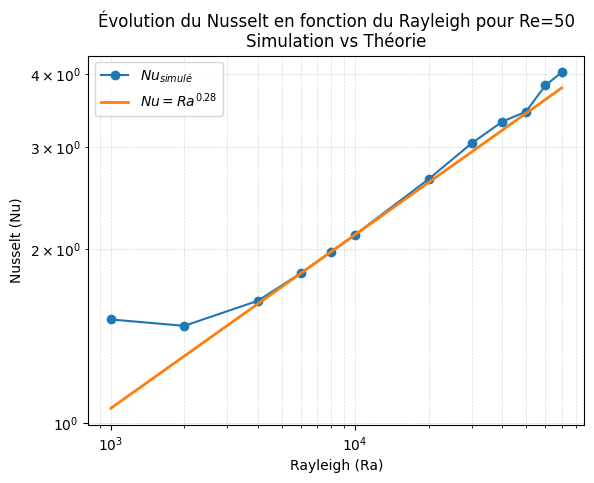

In [38]:
# ---- 1) Construire Nu_avg(Ra) ----
Ra_vals = []
Nu_avg_vals = []

for Ra in Ra_list:
    d = obj[dir_key][Re][Ra]
    nu_h = float(d["Nu_h"])
    nu_c = float(d["Nu_c"])
    nu_avg = (abs(nu_h) + abs(nu_c)) / 2.0

    Ra_vals.append(float(Ra))
    Nu_avg_vals.append(nu_avg)

Ra_vals = np.array(Ra_vals, dtype=float)
Nu_avg_vals = np.array(Nu_avg_vals, dtype=float)

idx = np.argsort(Ra_vals)
Ra_vals = Ra_vals[idx]
Nu_avg_vals = Nu_avg_vals[idx]

Ra_anchor = 1.0e4

mask = np.isclose(Ra_vals, Ra_anchor, rtol=0, atol=0)
if mask.any():
    Nu_anchor = float(Nu_avg_vals[mask][0])
else:
    Nu_anchor = float(np.interp(np.log10(Ra_anchor), np.log10(Ra_vals), np.log10(Nu_avg_vals)))
    Nu_anchor = 10 ** Nu_anchor

Nu_ref = Nu_anchor * (Ra_vals / Ra_anchor) ** 0.3

plt.figure()
plt.plot(Ra_vals, Nu_avg_vals, marker="o", linewidth=1.5, label=r"$Nu_{simulé}$")
plt.plot(Ra_vals, Nu_ref, linewidth=2.0, label=rf"$Nu = Ra^{{0.28}}$")

plt.xscale("log")
plt.yscale("log") 
plt.xlabel("Rayleigh (Ra)")
plt.ylabel("Nusselt (Nu)")
plt.title(f"Évolution du Nusselt en fonction du Rayleigh pour Re={Re}\nSimulation vs Théorie")
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend()

filename = f"Évolution du Nusselt en fonction du Rayleigh pour Re={Re}.png"
plt.savefig(os.path.join(out_dir, filename), dpi=200, bbox_inches="tight")

plt.show()